In [10]:
!pip install pandas
!pip install numpy 
!pip install matplotlib

In [11]:
!pip install --default-timeout=100 --retries 5 tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached grpcio-1.74.0-cp313-cp313-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached ml_dtypes-0.5.3-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using c

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Dell\anaconda3_new\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\Dell\anaconda3_new\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\Dell\anaconda3_new\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\Dell\anaconda3_new\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "C:\Users\Dell\anaconda3_new\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
  File "C:\Users\Dell\anaconda3_new\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~

   ------------ ------------------------- 105.4/332.0 MB 266.5 kB/s eta 0:14:11
   ------------ ------------------------- 105.4/332.0 MB 266.5 kB/s eta 0:14:11
   ------------ ------------------------- 105.6/332.0 MB 265.3 kB/s eta 0:14:14
   ------------ ------------------------- 105.6/332.0 MB 265.3 kB/s eta 0:14:14
   ------------ ------------------------- 105.6/332.0 MB 265.3 kB/s eta 0:14:14
   ------------ ------------------------- 105.6/332.0 MB 265.3 kB/s eta 0:14:14
   ------------ ------------------------- 105.6/332.0 MB 265.3 kB/s eta 0:14:14
   ------------ ------------------------- 105.9/332.0 MB 264.6 kB/s eta 0:14:15
   ------------ ------------------------- 105.9/332.0 MB 264.6 kB/s eta 0:14:15
   ------------ ------------------------- 106.2/332.0 MB 283.8 kB/s eta 0:13:16
   ------------ ------------------------- 106.2/332.0 MB 283.8 kB/s eta 0:13:16
   ------------ ------------------------- 106.2/332.0 MB 283.8 kB/s eta 0:13:16
   ------------ ------------------------

Synthetic Time-Series Data Created:


,patient_id,month,alt_level,scenario
0,0,0,74.827097,Worsening
1,0,1,84.591526,Worsening
2,0,2,87.438870,Worsening
3,0,3,88.354696,Worsening
4,0,4,87.690485,Worsening
5,0,5,93.312006,Worsening
6,0,6,84.562436,Worsening
7,0,7,90.111124,Worsening
8,0,8,85.177513,Worsening
9,0,9,97.556415,Worsening


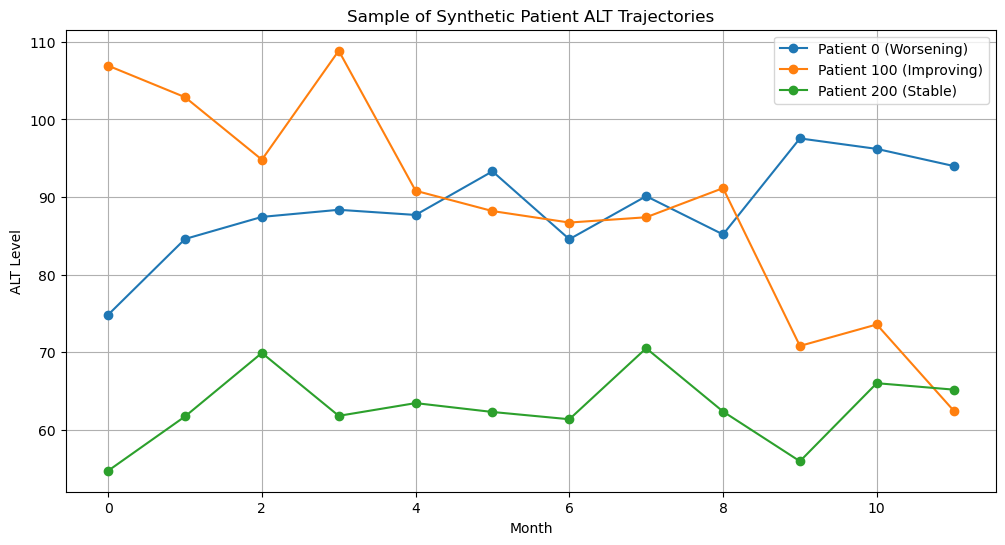

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define Simulation Parameters ---
n_patients = 100  # Number of patients per scenario
n_timesteps = 12  # Number of months to simulate

# --- 2. Create Patient Scenarios ---
data = []
patient_id_counter = 0

# Scenario A: Worsening Condition (e.g., untreated NAFLD)
for _ in range(n_patients):
    # ALT level starts high and trends upwards
    start_alt = np.random.uniform(80, 120)
    trend = np.linspace(0, 15, n_timesteps) # Gradual increase
    noise = np.random.normal(0, 5, n_timesteps) # Add realistic fluctuations
    alt_levels = start_alt + trend + noise
    for month in range(n_timesteps):
        data.append([patient_id_counter, month, alt_levels[month], 'Worsening'])
    patient_id_counter += 1
    
# Scenario B: Improving Condition (e.g., successful treatment)
for _ in range(n_patients):
    # ALT level starts high and trends downwards
    start_alt = np.random.uniform(90, 130)
    trend = np.linspace(0, -40, n_timesteps) # Gradual decrease
    noise = np.random.normal(0, 5, n_timesteps)
    alt_levels = start_alt + trend + noise
    for month in range(n_timesteps):
        data.append([patient_id_counter, month, alt_levels[month], 'Improving'])
    patient_id_counter += 1

# Scenario C: Stable Condition
for _ in range(n_patients):
    # ALT level stays in a stable, slightly elevated range
    start_alt = np.random.uniform(50, 70)
    noise = np.random.normal(0, 5, n_timesteps)
    alt_levels = start_alt + noise
    for month in range(n_timesteps):
        data.append([patient_id_counter, month, alt_levels[month], 'Stable'])
    patient_id_counter += 1

# --- 3. Create and Inspect the DataFrame ---
df_time_series = pd.DataFrame(data, columns=['patient_id', 'month', 'alt_level', 'scenario'])

print("Synthetic Time-Series Data Created:")
display(df_time_series.head(15)) # Show first 15 rows

# --- 4. Visualize the Data ---
plt.figure(figsize=(12, 6))
for i in [0, 100, 200]: # Plot one patient from each scenario
    patient_data = df_time_series[df_time_series['patient_id'] == i]
    plt.plot(patient_data['month'], patient_data['alt_level'], marker='o', linestyle='-', label=f'Patient {i} ({patient_data.iloc[0]["scenario"]})')

plt.title('Sample of Synthetic Patient ALT Trajectories')
plt.xlabel('Month')
plt.ylabel('ALT Level')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# --- 1. Prepare the data ---

# Scale the ALT levels to be between 0 and 1. Neural networks work best with scaled data.
scaler = MinMaxScaler(feature_range=(0, 1))
df_time_series['alt_scaled'] = scaler.fit_transform(df_time_series[['alt_level']])

# Create sequences. We'll use the last 3 months to predict the next month.
n_steps = 3
X, y = [], []

# Group by each patient and create sequences for them
for patient_id, group in df_time_series.groupby('patient_id'):
    scaled_levels = group['alt_scaled'].values
    for i in range(len(scaled_levels) - n_steps):
        # The input is a sequence of 3 months
        X.append(scaled_levels[i:i + n_steps])
        # The output is the 4th month
        y.append(scaled_levels[i + n_steps])

X, y = np.array(X), np.array(y)

# Reshape X to the format required by LSTM: [samples, timesteps, features]
# We have 1 feature: the ALT level.
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"Shape of the training data (X): {X.shape}")
print(f"Shape of the target data (y): {y.shape}")


# --- 2. Build and Train the LSTM model ---
print("\nBuilding the LSTM model...")
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print("Training the LSTM model...")
# The model learns from the data over 50 "epochs" or cycles.
model_lstm.fit(X, y, epochs=50, verbose=1)

print("\nTraining complete!")

Shape of the training data (X): (2700, 3, 1)
Shape of the target data (y): (2700,)

Building the LSTM model...


C:\Users\Dell\anaconda3_new\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the LSTM model...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1171 
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0074 
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0047 
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046   
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046 
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046   
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0044 
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0044  
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0044 
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0043  
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━

In [13]:
import joblib

# --- Step 3: Save the model and the scaler ---

# Save the trained LSTM model
model_lstm.save("lstm_progression_model.keras")

# Save the scaler object
joblib.dump(scaler, 'alt_scaler.pkl')

print("LSTM model and scaler have been saved successfully!")

LSTM model and scaler have been saved successfully!


In [1]:
conda install -c conda-forge rdkit

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
